Map colouring using CSP for territories in Australia

Solution:
{'WA': 'red', 'NT': 'green', 'SA': 'blue', 'Q': 'red', 'NSW': 'green', 'V': 'red', 'T': 'red'}


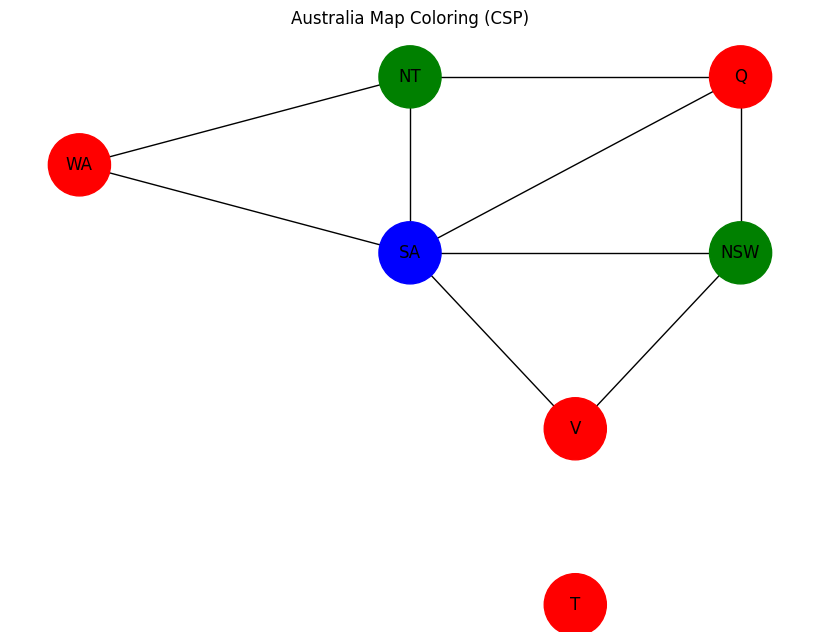

In [10]:
# Install required packages
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, TypeVar, Generic, Optional

# ---------- CSP IMPLEMENTATION (NO EXTERNAL LIB) ----------
V = TypeVar('V')
D = TypeVar('D')

class Constraint(Generic[V, D]):
    def __init__(self, variables: List[V]) -> None:
        self.variables = variables

    def satisfied(self, assignment: Dict[V, D]) -> bool:
        return True

class CSP(Generic[V, D]):
    def __init__(self, variables: List[V], domains: Dict[V, List[D]]) -> None:
        self.variables = variables
        self.domains = domains
        self.constraints: Dict[V, List[Constraint[V, D]]] = {}

        for variable in self.variables:
            self.constraints[variable] = []

    def add_constraint(self, constraint: Constraint[V, D]) -> None:
        for variable in constraint.variables:
            self.constraints[variable].append(constraint)

    def consistent(self, variable: V, assignment: Dict[V, D]) -> bool:
        for constraint in self.constraints[variable]:
            if not constraint.satisfied(assignment):
                return False
        return True

    def backtracking_search(self, assignment: Dict[V, D] = {}) -> Optional[Dict[V, D]]:
        if len(assignment) == len(self.variables):
            return assignment

        unassigned = [v for v in self.variables if v not in assignment]
        first = unassigned[0]

        for value in self.domains[first]:
            local_assignment = assignment.copy()
            local_assignment[first] = value

            if self.consistent(first, local_assignment):
                result = self.backtracking_search(local_assignment)
                if result is not None:
                    return result

        return None

# ---------- MAP COLORING CONSTRAINT ----------
class MapColoringConstraint(Constraint[str, str]):
    def __init__(self, place1: str, place2: str) -> None:
        super().__init__([place1, place2])
        self.place1 = place1
        self.place2 = place2

    def satisfied(self, assignment: Dict[str, str]) -> bool:
        if self.place1 not in assignment or self.place2 not in assignment:
            return True
        return assignment[self.place1] != assignment[self.place2]

# ---------- MAIN ----------
states = ["WA", "NT", "SA", "Q", "NSW", "V", "T"]

domains = {state: ["red", "green", "blue"] for state in states}

csp = CSP(states, domains)

edges = [
    ("WA", "NT"), ("WA", "SA"),
    ("NT", "SA"), ("NT", "Q"),
    ("SA", "Q"), ("SA", "NSW"), ("SA", "V"),
    ("Q", "NSW"),
    ("NSW", "V")
]

for (a, b) in edges:
    csp.add_constraint(MapColoringConstraint(a, b))

solution = csp.backtracking_search()

print("Solution:")
print(solution)

# ---------- VISUALIZATION ----------
G = nx.Graph()
G.add_nodes_from(states)
G.add_edges_from(edges)

pos = {
    "WA": (-2, 1),
    "NT": (0, 2),
    "SA": (0, 0),
    "Q": (2, 2),
    "NSW": (2, 0),
    "V": (1, -2),
    "T": (1, -4)
}

node_colors = [solution[state] for state in G.nodes]

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000)
plt.title("Australia Map Coloring (CSP)")
plt.show()

Map colouring on the states

Solution found!


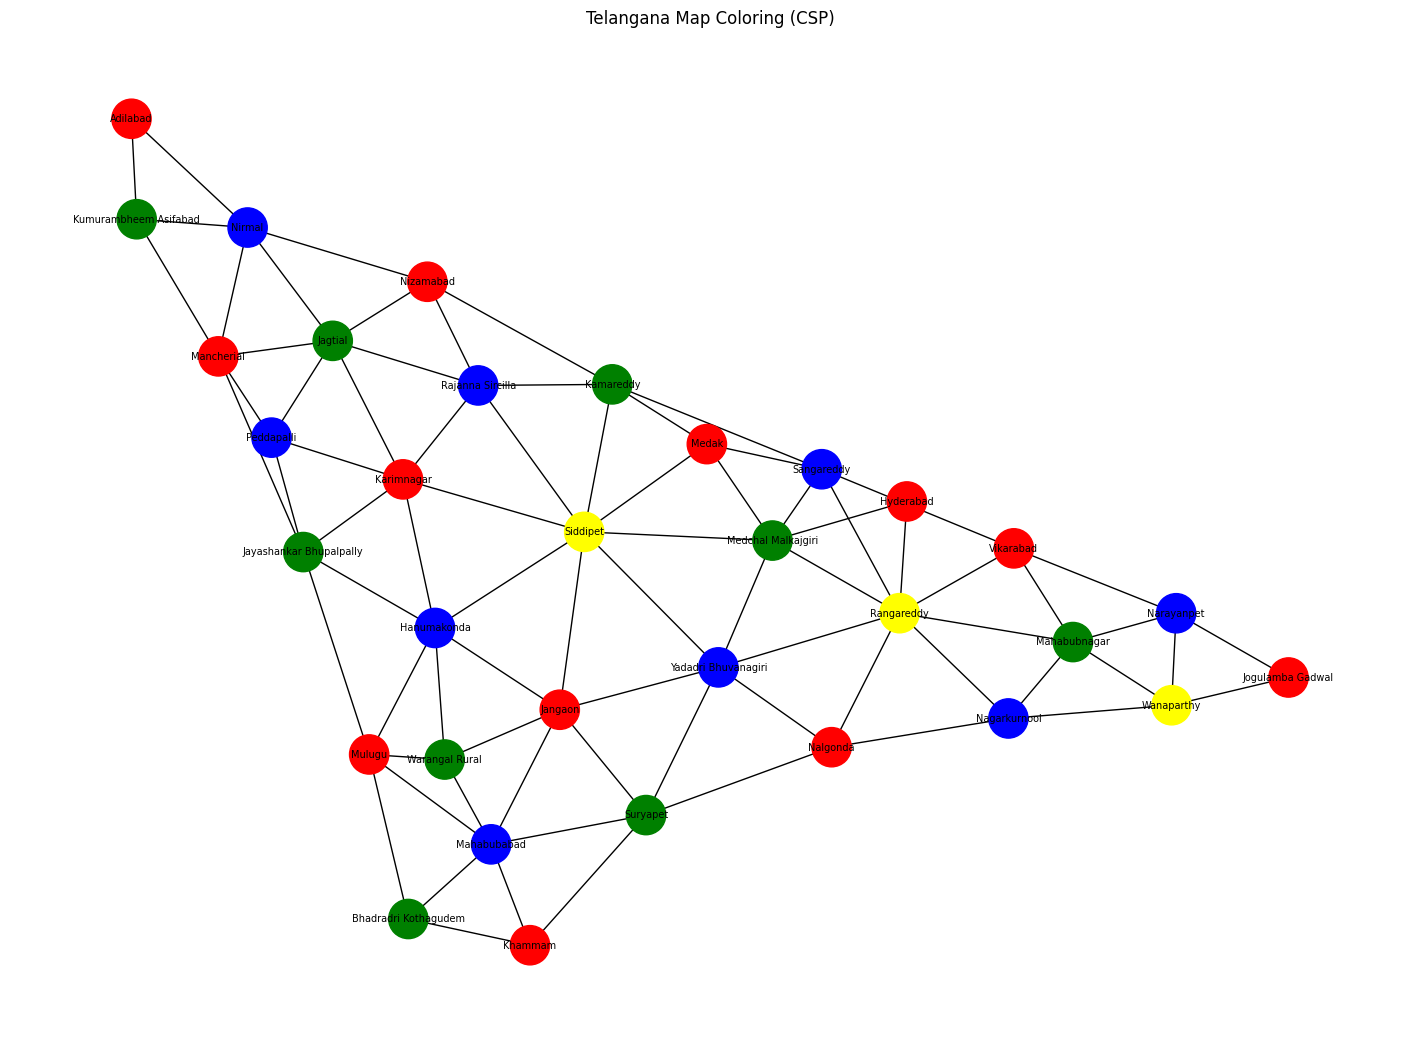

In [11]:
# Install required packages
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, TypeVar, Generic, Optional

# ---------- CSP IMPLEMENTATION ----------
V = TypeVar('V')
D = TypeVar('D')

class Constraint(Generic[V, D]):
    def __init__(self, variables: List[V]) -> None:
        self.variables = variables

    def satisfied(self, assignment: Dict[V, D]) -> bool:
        return True

class CSP(Generic[V, D]):
    def __init__(self, variables: List[V], domains: Dict[V, List[D]]) -> None:
        self.variables = variables
        self.domains = domains
        self.constraints: Dict[V, List[Constraint[V, D]]] = {}

        for variable in self.variables:
            self.constraints[variable] = []

    def add_constraint(self, constraint: Constraint[V, D]) -> None:
        for variable in constraint.variables:
            self.constraints[variable].append(constraint)

    def consistent(self, variable: V, assignment: Dict[V, D]) -> bool:
        for constraint in self.constraints[variable]:
            if not constraint.satisfied(assignment):
                return False
        return True

    def backtracking_search(self, assignment: Dict[V, D] = {}) -> Optional[Dict[V, D]]:
        if len(assignment) == len(self.variables):
            return assignment

        unassigned = [v for v in self.variables if v not in assignment]
        first = unassigned[0]

        for value in self.domains[first]:
            local_assignment = assignment.copy()
            local_assignment[first] = value

            if self.consistent(first, local_assignment):
                result = self.backtracking_search(local_assignment)
                if result is not None:
                    return result

        return None

# ---------- MAP COLORING CONSTRAINT ----------
class MapColoringConstraint(Constraint[str, str]):
    def __init__(self, place1: str, place2: str) -> None:
        super().__init__([place1, place2])
        self.place1 = place1
        self.place2 = place2

    def satisfied(self, assignment: Dict[str, str]) -> bool:
        if self.place1 not in assignment or self.place2 not in assignment:
            return True
        return assignment[self.place1] != assignment[self.place2]

# ---------- DATA ----------
variables = [
    "Adilabad", "Kumurambheem Asifabad", "Nirmal", "Mancherial",
    "Nizamabad", "Jagtial", "Peddapalli", "Jayashankar Bhupalpally",
    "Mulugu", "Bhadradri Kothagudem", "Kamareddy", "Rajanna Sircilla",
    "Karimnagar", "Hanumakonda", "Warangal Rural", "Mahabubabad",
    "Khammam", "Medak", "Siddipet", "Jangaon", "Suryapet",
    "Sangareddy", "Medchal Malkajgiri", "Yadadri Bhuvanagiri",
    "Nalgonda", "Vikarabad", "Rangareddy", "Hyderabad",
    "Mahabubnagar", "Narayanpet", "Jogulamba Gadwal", "Wanaparthy",
    "Nagarkurnool"
]

domains = {v: ["red", "green", "blue", "yellow"] for v in variables}

neighbors = {
    "Adilabad": ["Nirmal", "Kumurambheem Asifabad"],
    "Kumurambheem Asifabad": ["Adilabad", "Nirmal", "Mancherial"],
    "Nirmal": ["Adilabad", "Kumurambheem Asifabad", "Mancherial", "Jagtial", "Nizamabad"],
    "Mancherial": ["Kumurambheem Asifabad", "Nirmal", "Jagtial", "Peddapalli", "Jayashankar Bhupalpally"],
    "Nizamabad": ["Nirmal", "Jagtial", "Rajanna Sircilla", "Kamareddy"],
    "Jagtial": ["Nirmal", "Mancherial", "Peddapalli", "Karimnagar", "Rajanna Sircilla", "Nizamabad"],
    "Peddapalli": ["Mancherial", "Jayashankar Bhupalpally", "Karimnagar", "Jagtial"],
    "Jayashankar Bhupalpally": ["Mancherial", "Peddapalli", "Karimnagar", "Hanumakonda", "Mulugu"],
    "Mulugu": ["Jayashankar Bhupalpally", "Hanumakonda", "Warangal Rural", "Mahabubabad", "Bhadradri Kothagudem"],
    "Bhadradri Kothagudem": ["Mulugu", "Mahabubabad", "Khammam"],
    "Kamareddy": ["Nizamabad", "Rajanna Sircilla", "Siddipet", "Medak", "Sangareddy"],
    "Rajanna Sircilla": ["Nizamabad", "Jagtial", "Karimnagar", "Siddipet", "Kamareddy"],
    "Karimnagar": ["Jagtial", "Peddapalli", "Jayashankar Bhupalpally", "Hanumakonda", "Siddipet", "Rajanna Sircilla"],
    "Hanumakonda": ["Jayashankar Bhupalpally", "Warangal Rural", "Jangaon", "Siddipet", "Karimnagar"],
    "Warangal Rural": ["Hanumakonda", "Mulugu", "Mahabubabad", "Jangaon"],
    "Mahabubabad": ["Warangal Rural", "Mulugu", "Bhadradri Kothagudem", "Khammam", "Suryapet", "Jangaon"],
    "Khammam": ["Bhadradri Kothagudem", "Mahabubabad", "Suryapet"],
    "Medak": ["Kamareddy", "Siddipet", "Medchal Malkajgiri", "Sangareddy"],
    "Siddipet": ["Kamareddy", "Rajanna Sircilla", "Karimnagar", "Hanumakonda", "Jangaon", "Yadadri Bhuvanagiri", "Medchal Malkajgiri", "Medak"],
    "Jangaon": ["Siddipet", "Hanumakonda", "Warangal Rural", "Mahabubabad", "Suryapet", "Yadadri Bhuvanagiri"],
    "Suryapet": ["Jangaon", "Mahabubabad", "Khammam", "Nalgonda", "Yadadri Bhuvanagiri"],
    "Sangareddy": ["Kamareddy", "Medak", "Medchal Malkajgiri", "Rangareddy", "Vikarabad"],
    "Medchal Malkajgiri": ["Medak", "Siddipet", "Yadadri Bhuvanagiri", "Rangareddy", "Hyderabad", "Sangareddy"],
    "Yadadri Bhuvanagiri": ["Siddipet", "Jangaon", "Suryapet", "Nalgonda", "Rangareddy", "Medchal Malkajgiri"],
    "Nalgonda": ["Yadadri Bhuvanagiri", "Suryapet", "Nagarkurnool", "Rangareddy"],
    "Vikarabad": ["Sangareddy", "Rangareddy", "Mahabubnagar", "Narayanpet"],
    "Rangareddy": ["Vikarabad", "Sangareddy", "Medchal Malkajgiri", "Hyderabad", "Yadadri Bhuvanagiri", "Nalgonda", "Nagarkurnool", "Mahabubnagar"],
    "Hyderabad": ["Medchal Malkajgiri", "Rangareddy"],
    "Mahabubnagar": ["Vikarabad", "Rangareddy", "Nagarkurnool", "Wanaparthy", "Narayanpet"],
    "Narayanpet": ["Vikarabad", "Mahabubnagar", "Wanaparthy", "Jogulamba Gadwal"],
    "Jogulamba Gadwal": ["Narayanpet", "Wanaparthy"],
    "Wanaparthy": ["Jogulamba Gadwal", "Narayanpet", "Mahabubnagar", "Nagarkurnool"],
    "Nagarkurnool": ["Wanaparthy", "Mahabubnagar", "Rangareddy", "Nalgonda"]
}

# ---------- CSP SETUP ----------
csp = CSP(variables, domains)

edges = set()
for district, adj in neighbors.items():
    for a in adj:
        edges.add(tuple(sorted((district, a))))
        csp.add_constraint(MapColoringConstraint(district, a))

solution = csp.backtracking_search()

print("Solution found!")

# ---------- GRAPH VISUALIZATION ----------
G = nx.Graph()
G.add_nodes_from(variables)
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)  # auto layout

node_colors = [solution[node] for node in G.nodes]

plt.figure(figsize=(14,10))
nx.draw(G, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=800,
        font_size=7)

plt.title("Telangana Map Coloring (CSP)")
plt.show()

sudoku puzzle

In [12]:
from typing import Dict, List, TypeVar, Generic, Optional

# ---------- CSP IMPLEMENTATION ----------
V = TypeVar('V')
D = TypeVar('D')

class Constraint(Generic[V, D]):
    def __init__(self, variables: List[V]) -> None:
        self.variables = variables

    def satisfied(self, assignment: Dict[V, D]) -> bool:
        return True

class CSP(Generic[V, D]):
    def __init__(self, variables: List[V], domains: Dict[V, List[D]]) -> None:
        self.variables = variables
        self.domains = domains
        self.constraints: Dict[V, List[Constraint[V, D]]] = {}

        for variable in self.variables:
            self.constraints[variable] = []

    def add_constraint(self, constraint: Constraint[V, D]) -> None:
        for variable in constraint.variables:
            self.constraints[variable].append(constraint)

    def consistent(self, variable: V, assignment: Dict[V, D]) -> bool:
        for constraint in self.constraints[variable]:
            if not constraint.satisfied(assignment):
                return False
        return True

    def backtracking_search(self, assignment: Dict[V, D] = {}) -> Optional[Dict[V, D]]:
        if len(assignment) == len(self.variables):
            return assignment

        unassigned = [v for v in self.variables if v not in assignment]
        first = unassigned[0]

        for value in self.domains[first]:
            local_assignment = assignment.copy()
            local_assignment[first] = value

            if self.consistent(first, local_assignment):
                result = self.backtracking_search(local_assignment)
                if result is not None:
                    return result

        return None

# ---------- SUDOKU CONSTRAINT ----------
class SudokuConstraint(Constraint[str, int]):
    def __init__(self, variables: List[str]) -> None:
        super().__init__(variables)

    def satisfied(self, assignment: Dict[str, int]) -> bool:
        values = [assignment[v] for v in self.variables if v in assignment]
        return len(values) == len(set(values))

# ---------- SETUP ----------
rows = "ABCDEFGHI"
cols = "123456789"

variables = [r + c for r in rows for c in cols]

initial_grid = {
    'A3': 3, 'A5': 2, 'A7': 6,
    'B1': 9, 'B4': 3, 'B6': 5, 'B9': 1,
    'C3': 1, 'C4': 8, 'C6': 6, 'C7': 4,
    'D3': 8, 'D4': 1, 'D6': 2, 'D7': 9,
    'E1': 7, 'E9': 8,
    'F3': 6, 'F4': 7, 'F6': 8, 'F7': 2,
    'G3': 2, 'G4': 6, 'G6': 9, 'G7': 5,
    'H1': 8, 'H4': 2, 'H6': 3, 'H9': 9,
    'I3': 5, 'I5': 1, 'I7': 3
}

domains = {}
for var in variables:
    if var in initial_grid:
        domains[var] = [initial_grid[var]]
    else:
        domains[var] = list(range(1, 10))

csp = CSP(variables, domains)

# Rows
for r in rows:
    csp.add_constraint(SudokuConstraint([r + c for c in cols]))

# Columns
for c in cols:
    csp.add_constraint(SudokuConstraint([r + c for r in rows]))

# 3x3 Blocks
for r0 in [0, 3, 6]:
    for c0 in [0, 3, 6]:
        block = []
        for i in range(3):
            for j in range(3):
                block.append(rows[r0 + i] + cols[c0 + j])
        csp.add_constraint(SudokuConstraint(block))

# ---------- SOLVE ----------
print("Solving Sudoku...")
solution = csp.backtracking_search()

# ---------- DISPLAY ----------
if solution is None:
    print("No solution found!")
else:
    print("\nSolved Sudoku:\n")

    for i, r in enumerate(rows):
        row_vals = []
        for j, c in enumerate(cols):
            row_vals.append(str(solution[r + c]))

            if (j + 1) % 3 == 0 and j < 8:
                row_vals.append("|")

        print(" ".join(row_vals))

        if (i + 1) % 3 == 0 and i < 8:
            print("-" * 21)

Solving Sudoku...

Solved Sudoku:

4 8 3 | 9 2 1 | 6 5 7
9 6 7 | 3 4 5 | 8 2 1
2 5 1 | 8 7 6 | 4 9 3
---------------------
5 4 8 | 1 3 2 | 9 7 6
7 2 9 | 5 6 4 | 1 3 8
1 3 6 | 7 9 8 | 2 4 5
---------------------
3 7 2 | 6 8 9 | 5 1 4
8 1 4 | 2 5 3 | 7 6 9
6 9 5 | 4 1 7 | 3 8 2


crypt analysis puzzle

In [13]:
from typing import Dict, List, TypeVar, Generic, Optional

# ---------- CSP IMPLEMENTATION ----------
V = TypeVar('V')
D = TypeVar('D')

class Constraint(Generic[V, D]):
    def __init__(self, variables: List[V]) -> None:
        self.variables = variables

    def satisfied(self, assignment: Dict[V, D]) -> bool:
        return True

class CSP(Generic[V, D]):
    def __init__(self, variables: List[V], domains: Dict[V, List[D]]) -> None:
        self.variables = variables
        self.domains = domains
        self.constraints: Dict[V, List[Constraint[V, D]]] = {}

        for variable in self.variables:
            self.constraints[variable] = []

    def add_constraint(self, constraint: Constraint[V, D]) -> None:
        for variable in constraint.variables:
            self.constraints[variable].append(constraint)

    def consistent(self, variable: V, assignment: Dict[V, D]) -> bool:
        for constraint in self.constraints[variable]:
            if not constraint.satisfied(assignment):
                return False
        return True

    def backtracking_search(self, assignment: Dict[V, D] = {}) -> Optional[Dict[V, D]]:
        if len(assignment) == len(self.variables):
            return assignment

        unassigned = [v for v in self.variables if v not in assignment]
        first = unassigned[0]

        for value in self.domains[first]:
            local_assignment = assignment.copy()
            local_assignment[first] = value

            if self.consistent(first, local_assignment):
                result = self.backtracking_search(local_assignment)
                if result is not None:
                    return result

        return None

# ---------- CRYPTARITHMETIC CONSTRAINT ----------
class CryptarithmeticConstraint(Constraint[str, int]):
    def __init__(self, letters: List[str]) -> None:
        super().__init__(letters)

    def satisfied(self, assignment: Dict[str, int]) -> bool:
        letters = ["T", "W", "O", "F", "U", "R"]

        # All letters must have unique digits
        assigned = [assignment[l] for l in letters if l in assignment]
        if len(assigned) != len(set(assigned)):
            return False

        # If all assigned → check equation
        if len(assignment) == len(self.variables):
            t, w, o = assignment["T"], assignment["W"], assignment["O"]
            f, u, r = assignment["F"], assignment["U"], assignment["R"]
            c1, c2, c3 = assignment["C1"], assignment["C2"], assignment["C3"]

            # Leading digits cannot be 0
            if t == 0 or f == 0:
                return False

            # Column-wise addition
            if o + o != r + 10 * c1:
                return False
            if w + w + c1 != u + 10 * c2:
                return False
            if t + t + c2 != o + 10 * c3:
                return False
            if f != c3:
                return False

        return True

# ---------- SETUP ----------
variables = ["T", "W", "O", "F", "U", "R", "C1", "C2", "C3"]

domains = {}

for letter in ["T", "W", "O", "F", "U", "R"]:
    domains[letter] = list(range(10))

for carry in ["C1", "C2", "C3"]:
    domains[carry] = [0, 1]

csp = CSP(variables, domains)
csp.add_constraint(CryptarithmeticConstraint(variables))

# ---------- SOLVE ----------
print("Solving TWO + TWO = FOUR...\n")
solution = csp.backtracking_search()

# ---------- OUTPUT ----------
if solution is None:
    print("No solution found!")
else:
    t, w, o = solution["T"], solution["W"], solution["O"]
    f, u, r = solution["F"], solution["U"], solution["R"]

    print("Solution:\n")
    print(f"   {t}{w}{o}")
    print(f"+  {t}{w}{o}")
    print("---------")
    print(f"  {f}{o}{u}{r}")

    print("\nDetailed Assignment:")
    print(solution)

Solving TWO + TWO = FOUR...

Solution:

   734
+  734
---------
  1468

Detailed Assignment:
{'T': 7, 'W': 3, 'O': 4, 'F': 1, 'U': 6, 'R': 8, 'C1': 0, 'C2': 0, 'C3': 1}
